# <b>Assignment 2: Multi-Layer Perceptrons (MLP) Network</b>

## Group: Bone Fracture

### Contributors
1. Laura Telle  
2. Allison Young  
3. Vanessa Lukasser  

This notebook implements a shallow Multi-Layer Perceptron (MLP) for fracture image classification using the preprocessed dataset from Assignment 1.



# Objectives

1. Load preprocessed image data  
2. Apply image augmentation during loading  
3. Build and train a shallow MLP network  
4. Evaluate the network performance  
5. Observe learning curves  
6. Interpret results and suggest improvements  

> Note: CNNs are NOT used in this assignment.


## Import Required Libraries

In [228]:
# Import standard Python libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import type hints for lists and tuples
from typing import List, Tuple

# Import tools for file and folder handling
from pathlib import Path
import shutil
import random

# Import image processing library
from PIL import Image

# Import PyTorch libraries for deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import Optimizer

# Import utilities for datasets and data loading
from torch.utils.data import Dataset, DataLoader

# Import image transformations such as resizing and grayscale conversion
from torchvision import transforms

# Import evaluation metrics for model performance analysis
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Import progress bar for training loops
from tqdm import tqdm

# Import tools for K-Fold cross validation
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset  # Import dataset subset utility

## Random Seed to Reproduce result

In [180]:
SEED = 123 # Set a fixed random seed for reproducibility
random.seed(SEED) # Set seed for Python's random module
np.random.seed(SEED) # Set seed for NumPy random operations
torch.manual_seed(SEED) # Set seed for PyTorch CPU operations

# Set seed for PyTorch GPU operations if CUDA is available
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED) # Seed current GPU
    torch.cuda.manual_seed_all(SEED) # Seed all available GPUs

torch.backends.cudnn.deterministic = True # Ensure deterministic behavior for reproducible results
torch.backends.cudnn.benchmark = False # Disable CuDNN auto-optimization for consistent results

## Device Configuration

In [181]:
# checks whether the computer has a compatible GPU available for PyTorch, and chooses the best device to run the code on.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Predefine Training Function

In [182]:
def train_network(model,
                  train_loader,
                  val_loader,
                  criterion,
                  optimizer:Optimizer,
                  epochs):
    """
    Train and validate a neural network model.

    Parameters
    ----------
    model : torch.nn.Module
        Neural network model to train.

    train_loader : DataLoader
        DataLoader containing training data.

    val_loader : DataLoader
        DataLoader containing validation data.

    criterion : loss function
        Loss function used to measure prediction error.

    optimizer : torch.optim
        Optimizer used to update model weights.

    epochs : int
        Number of training epochs.

    Returns
    -------
    train_losses : list
        Average training loss for each epoch.

    val_losses : list
        Average validation loss for each epoch.
    """
    train_losses = []  # Store training losses
    val_losses = []  # Store validation losses

    # Loop through all training epochs
    for epoch in range(epochs):

        #  TRAINING
        model.train()  # Set model to training mode
        running_loss = 0  # Store total training loss

        # Loop through training batches
        for images, labels in tqdm(train_loader):
            images = images.to(device)  # Move images to selected device
            labels = labels.to(device).unsqueeze(1)  # Add extra label dimension for binary classification
            optimizer.zero_grad()  # Clear previous gradients
            outputs = model(images)  # Forward pass through the model
            loss = criterion(outputs, labels)  # Compute training loss
            loss.backward()  # Compute gradients using backpropagation
            optimizer.step()  # Update model weights
            running_loss += loss.item()  # Accumulate batch loss

        train_loss = running_loss / len(train_loader)  # Compute average training loss
        train_losses.append(train_loss)  # Store training loss

        #  VALIDATION
        model.eval()  # Set model to evaluation mode
        val_running_loss = 0  # Store total validation loss

        with torch.no_grad(): # Disable gradient calculations during validation

            # Loop through validation batches
            for images, labels in val_loader:
                images = images.to(device)  # Move images to selected device
                labels = labels.to(device).unsqueeze(1)  # Add extra label dimension
                outputs = model(images)  # Forward pass through the model
                loss = criterion(outputs, labels)  # Compute validation loss
                val_running_loss += loss.item()  # Accumulate validation loss

        val_loss = val_running_loss / len(val_loader)  # Compute average validation loss
        val_losses.append(val_loss)  # Store validation loss

        # RESULTS
        print(f"Epoch [{epoch + 1}/{epochs}]")  # Print current epoch
        print(f"Train Loss      : {train_loss:.4f}")  # Print training loss
        print(f"Validation Loss : {val_loss:.4f}")  # Print validation loss

    return train_losses, val_losses  # Return stored losses

## Predefine Evaluation Function

In [183]:
def evaluate_model(model,
                   test_loader,
                   model_name="Model",
                   summary=True)-> Tuple[
                       float,
                       float,
                       float,
                       float,
                       List,
                       List
                   ]:
    """
    Evaluate a trained neural network on test data.

    Parameters
    ----------
    model : torch.nn.Module
        Trained neural network model.

    test_loader : DataLoader
        DataLoader containing test data.

    model_name : str, optional
        Name of the model used when printing results.

    summary : bool, optional
        If True, evaluation metrics are printed.

    Returns
    -------
    accuracy : float
        Classification accuracy score.

    precision : float
        Precision score of the model.

    recall : float
        Recall score of the model.

    f1 : float
        F1-score of the model.

    y_true : list
        Ground truth labels.

    y_pred : list
        Predicted labels.
    """
    model.eval()  # Set model to evaluation mode
    y_true = []  # Store true labels
    y_pred = []  # Store predicted labels

    with torch.no_grad(): # Disable gradient calculations during evaluation

        # Loop through test batches
        for images, labels in test_loader:
            images = images.to(device)  # Move images to selected device
            outputs = model(images)  # Forward pass through the model
            probabilities = torch.sigmoid(outputs)  # Convert logits to probabilities
            predictions = (probabilities > 0.5).float()  # Convert probabilities to binary predictions
            y_true.extend(labels.numpy())  # Store true labels
            y_pred.extend(predictions.cpu().numpy().flatten())  # Store predicted labels

    # METRICS
    accuracy = accuracy_score(y_true, y_pred)  # Compute accuracy score
    precision = precision_score(y_true, y_pred)  # Compute precision score
    recall = recall_score(y_true, y_pred)  # Compute recall score
    f1 = f1_score(y_true, y_pred)  # Compute F1-score

    # RESULTS
    # Print evaluation summary
    if summary:
        print(f"\n{model_name} Evaluation")  # Print model name
        print(f"Accuracy : {accuracy:.4f}")  # Print accuracy score
        print(f"Precision: {precision:.4f}")  # Print precision score
        print(f"Recall   : {recall:.4f}")  # Print recall score
        print(f"F1 Score : {f1:.4f}")  # Print F1-score

    return accuracy, precision, recall, f1, y_true, y_pred  # Return evaluation results

## Predefine Initialization Function

In [184]:
def model_summary(model,
                  learning_rate,
                  model_name="Model"):
    """
    Print a summary of the neural network model.

    Parameters
    ----------
    model : torch.nn.Module
        Neural network model to summarize.

    learning_rate : float
        Learning rate used during training.

    model_name : str, optional
        Name of the model displayed in the summary.

    Returns
    -------
    model : torch.nn.Module
        The input model.
    """
    total_params = sum(p.numel() for p in model.parameters())  # Count total number of parameters
    trainable_params = sum(p.numel() for p in model.parameters()if p.requires_grad) # Count trainable parameters only

    # MODEL SUMMARY
    print("\n==============================")
    print(f"{model_name.upper()} SUMMARY")  # Print model name
    print("==============================")
    print(model)  # Print model architecture
    print("\n------------------------------")
    print(f"Total Parameters     : {total_params:,}")  # Print total parameter count
    print(f"Trainable Parameters : {trainable_params:,}")  # Print trainable parameter count
    print(f"Learning Rate        : {learning_rate}")  # Print learning rate
    print("------------------------------")

    return model  # Return model

## Predefine Plot Learning Curve Function

In [185]:
def plot_learning_curves(train_losses, val_losses):
    """
    Plot training and validation loss curves.

    Parameters
    ----------
    train_losses : list
        Training loss values for each epoch.

    val_losses : list
        Validation loss values for each epoch.
    """
    plt.figure(figsize=(8, 5))  # Create figure
    plt.plot(train_losses, label="Training Loss")  # Plot training loss
    plt.plot(val_losses, label="Validation Loss")  # Plot validation loss
    plt.xlabel("Epoch")  # Add x-axis label
    plt.ylabel("Loss")  # Add y-axis label
    plt.title("Learning Curves")  # Add plot title
    plt.legend()  # Show legend
    plt.show()  # Display plot

## Predefine Plot Confusion Matrix Function

In [186]:
def plot_confusion_matrix(evaluation_results):
    """
    Plot a confusion matrix for model predictions.

    Parameters
    ----------
    evaluation_results : tuple
        Tuple returned from the evaluate_model() function.
        Must contain:
        - y_true at index 4
        - y_pred at index 5
    """
    cm = confusion_matrix(evaluation_results[4], evaluation_results[5])  # Create confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Fracture", "Normal"])  # Create confusion matrix display
    disp.plot()  # Plot confusion matrix
    plt.title("Confusion Matrix")  # Add plot title
    plt.show()  # Display plot

# 1. Load preprocessed data from Assignment 1

The dataset consists of 108 bone images used for fracture detection, organized into two distinct folders based on their condition:

- Normal: 77 images of healthy bones
- Fractured: 31 images of fractured bones

The images are preprocessed and share a standardized resolution of $224 \times 224$ pixels.

## Dataset Split

In [187]:
SOURCE_DIR = Path("Dataset_processed")  # Define source dataset folder
OUTPUT_DIR = Path("Dataset_split")  # Define output dataset folder

# Remove old dataset split folder if it already exists
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

train_ratio = 0.70  # Define training split ratio
val_ratio = 0.15  # Define validation split ratio
test_ratio = 0.15  # Define test split ratio

fracture_ids = set(pd.read_excel("Fractures.xlsx", header=None)[0].astype(int))  # Load valid fracture image IDs from Excel file
normal_ids = set(pd.read_excel("Normals.xlsx",header=None)[0].astype(int))  # Load valid normal image IDs from Excel file
allowed_ids = {"fracture": fracture_ids,"normal": normal_ids}  # Store valid image IDs for each class
classes = ["fracture", "normal"]  # Define dataset classes

# Loop through each class folder
for cls in classes:
    source_folder = SOURCE_DIR / cls  # Path to class folder
    all_images = list(source_folder.glob("*"))  # Get all image files in folder
    valid_images = []  # Store only valid images

    # Loop through all images
    for image_path in all_images:
        number = int(image_path.stem.split("_")[-1])  # Extract image number from filename
        # Keep image only if number exists in Excel file
        if number in allowed_ids[cls]:
            valid_images.append(image_path)

    random.shuffle(valid_images)  # Shuffle images randomly
    total = len(valid_images)  # Count total number of selected images
    train_end = int(total * train_ratio)  # Compute training split index
    val_end = train_end + int(total * val_ratio)  # Compute validation split index

    # Split images into train, validation, and test sets
    splits = {
        "train": valid_images[:train_end],
        "val": valid_images[train_end:val_end],
        "test": valid_images[val_end:]
    }
    print(f"\n{cls.upper()}")  # Print class name
    print(f"Total selected images: {total}")  # Print total image count
    print(f"Train: {len(splits['train'])}")  # Print training set size
    print(f"Validation: {len(splits['val'])}")  # Print validation set size
    print(f"Test: {len(splits['test'])}")  # Print test set size

    # Loop through each dataset split
    for split_name, split_images in splits.items():
        split_folder = OUTPUT_DIR / split_name / cls  # Create destination folder path
        split_folder.mkdir(parents=True, exist_ok=True)  # Create destination folder if it does not exist

        # Copy images into corresponding split folder
        for image_path in split_images:
            destination = split_folder / image_path.name  # Define destination image path
            shutil.copy(image_path, destination)  # Copy image to destination folder

print("\nDataset successfully split.")  # Print completion message


FRACTURE
Total selected images: 77
Train: 53
Validation: 11
Test: 13

NORMAL
Total selected images: 31
Train: 21
Validation: 4
Test: 6

Dataset successfully split.


## Define Image Transformations

Data augmentation is applied to improve generalization and reduce overfitting.


In [188]:
# Define image size used for model input
image_resize_size = 224

# Image transformations applied to training data
train_transform = transforms.Compose([
    transforms.Resize((image_resize_size, image_resize_size)), # Resize images to fixed dimensions
    transforms.RandomHorizontalFlip(), # Randomly flip images horizontally for data augmentation
    transforms.Grayscale(num_output_channels=1), # Convert RGB images to grayscale (1 channel)
    transforms.RandomRotation(10), # Randomly rotate images up to ±10 degrees
    transforms.ToTensor(),]) # Convert image to PyTorch tensor

# Image transformations applied to validation and test data
test_transform = transforms.Compose([
    transforms.Resize((image_resize_size, image_resize_size)), # Resize images to fixed dimensions
    transforms.Grayscale(num_output_channels=1), # Convert RGB images to grayscale (1 channel)
    transforms.ToTensor(),]) # Convert image to PyTorch tensor

## Custom Dataset Class

In the next step, a custom PyTorch Dataset class is implemented, utilizing the standard len and getitem methods to automatically load images and convert them into PyTorch tensors. This structures the data into a format PyTorch understands, enabling the use of DataLoader components for efficient batching and shuffling during training.

Additionally, data augmentation techniques are integrated into the dataset pipeline to enhance model robustness and prevent overfitting. Because these transformations are applied within the getitem method, a new randomized variation of the images is generated at every epoch, providing the model with different training variations throughout the process.

In [189]:
class FractureDataset(Dataset):
    """
    Custom PyTorch dataset for fracture classification.

    Parameters
    ----------
    root_dir : str
        Path to dataset directory containing class folders.

    transform : torchvision.transforms, optional
        Image transformations applied to each image.

    Attributes
    ----------
    samples : list
        List containing tuples of image paths and labels.

    class_to_idx : dict
        Dictionary mapping class names to numeric labels.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir  # Store dataset directory path
        self.transform = transform  # Store image transformations
        self.samples = []  # Store image paths and labels
        class_names = sorted(os.listdir(root_dir))  # Get class folder names and sort alphabetically
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)} # Create mapping from class names to numeric labels

        # Loop through each class folder
        for cls_name in class_names:
            cls_folder = os.path.join(root_dir,cls_name)  # Path to class folder
            # Loop through all images in class folder
            for img_name in os.listdir(cls_folder):
                img_path = os.path.join(cls_folder,img_name)  # Create full image path
                self.samples.append((img_path,self.class_to_idx[cls_name]))  # Store image path and label

    def __len__(self):
        """
        Return total number of samples in dataset.
        """
        return len(self.samples)  # Return dataset size

    def __getitem__(self, idx):
        """
        Retrieve one sample from the dataset.

        Parameters
        ----------
        idx : int
            Index of sample.

        Returns
        -------
        image : torch.Tensor
            Transformed image tensor.

        label : torch.Tensor
            Corresponding image label.
        """
        img_path, label = self.samples[idx]  # Get image path and label
        image = Image.open(img_path) # Open image
        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)  # Return image tensor and label tensor

## Load Datasets

Separate instances of the custom dataset were then created for the training, validation, and test sets. Data augmentation is applied only to the training subset while the validation and test images remain unaltered.

In [190]:
# Define dataset directory paths
train_dir = "Dataset_split/train"
val_dir = "Dataset_split/val"
test_dir = "Dataset_split/test"

train_dataset = FractureDataset(train_dir, transform=train_transform) # Create training dataset with data augmentation transforms
val_dataset = FractureDataset(val_dir,transform=test_transform) # Create validation dataset with test transforms
test_dataset = FractureDataset(test_dir,transform=test_transform) # Create test dataset with test transforms

# Print dataset sizes
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))


Train size: 74
Validation size: 15
Test size: 19


## Create DataLoaders

Finally, PyTorch DataLoaders were created for all three datasets to divide the data into $n$ batches based on a specified batch size. Shuffling was enabled only for the training DataLoader (shuffle=True) to reorder the images at each epoch, preventing the model from learning order-based patterns and ensuring more effective generalization.

In [191]:
# Define number of samples per batch
batch_size = 32

# Create DataLoader for training data
# shuffle=True randomly shuffles data each epoch
training_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Create DataLoader for validation data
# shuffle=False keeps data order fixed
validation_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Create DataLoader for test data
# shuffle=False keeps data order fixed
testing_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Visualize Sample Images


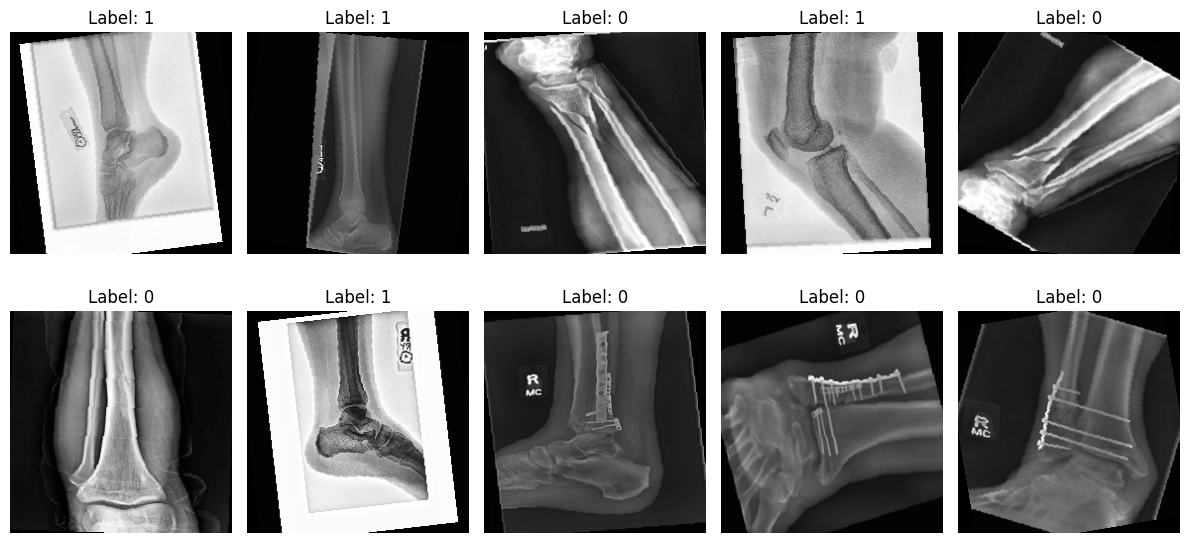

In [192]:
# Get one batch of images and labels from the training DataLoader
ex_images, ex_labels = next(iter(training_loader))

# Create figure with 2 rows and 5 columns
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

# Loop through subplot axes
for i, ax in enumerate(axes.flat):
    # Rearrange image dimensions from (channels, height, width) to (height, width, channels)
    img = ex_images[i].permute(1, 2, 0)
    ax.imshow(img, cmap="gray") # Display image in grayscale
    ax.set_title(f"Label: {int(ex_labels[i].item())}") # Display image label
    ax.axis("off") # Remove axis ticks

plt.tight_layout() # Adjust subplot spacing
plt.show() # Display figure


# 2. Build, train, and evaluate a shallow network

## Build the Shallow Model

A simple shallow Network architecture was defined, consisting of an initial linear layer followed by a ReLU activation function to introduce non-linearity, and a final linear output layer.

In [193]:
class SimpleMLP(nn.Module):
    """
    Simple Multi-Layer Perceptron (MLP)
    for binary image classification.

    Architecture
    ------------
    Input Layer:
        Flattened grayscale image

    Hidden Layer:
        128 neurons with ReLU activation

    Output Layer:
        1 neuron for binary classification
    """

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten() # Flatten image tensor into a 1D vector

        # Define fully connected neural network
        self.network = nn.Sequential(

            nn.Linear(image_resize_size * image_resize_size,128),

            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        """
        Perform forward pass through the network.

        Parameters
        ----------
        x : torch.Tensor
            Input image batch.

        Returns
        -------
        torch.Tensor
            Model output logits.
        """

        x = self.flatten(x) # Flatten input image


        return self.network(x) # Forward pass through network

## Initialize the Shallow Model

An instance of the shallow network was created with an input size of 50,176 ($224 \times 224 \times 1$ flattened grayscale pixels). The model architecture and parameter count were verified using the `model_summary()` function to confirm the structure of the network layers.

First Linear Layer (50,176 inputs to 128 outputs):
- Weights: $50,176 \times 128 = 6,422,528$
- Biases: $128$
- Total for Layer: $6,422,656$

Second Linear Layer (128 inputs to 1 output):
- Weights: $128 \times 1 = 128$
- Biases: $1$
- Total for Layer: $129$

Grand Total: $6,422,656 + 129 = \mathbf{6,422,785}$

In [194]:
lr = 0.001 # Define learning rate for optimizer
shallow_model = SimpleMLP().to(device) # Create model and move it to selected device (CPU or GPU)
loss_function = nn.BCEWithLogitsLoss() # Define binary classification loss function
adam_optimizer = optim.Adam(shallow_model.parameters(), lr=lr) # Define Adam optimizer
model_summary(shallow_model, lr,model_name="Shallow Network") # Print model summary


SHALLOW NETWORK SUMMARY
SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=50176, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

------------------------------
Total Parameters     : 6,422,785
Trainable Parameters : 6,422,785
Learning Rate        : 0.001
------------------------------


SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=50176, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

## Train the Shallow Model

In [195]:
# Define number of training epochs
num_epochs = 100

# Train model and store loss values
shallow_train_losses, shallow_val_losses = train_network(
    shallow_model, # Neural network model
    training_loader, # Training DataLoader
    validation_loader, # Validation DataLoader
    loss_function, # Loss function
    adam_optimizer, # Optimizer
    epochs=num_epochs) # Number of epochs

100%|██████████| 3/3 [00:00<00:00, 10.95it/s]


Epoch [1/100]
Train Loss      : 2.8289
Validation Loss : 0.9453


100%|██████████| 3/3 [00:00<00:00, 41.40it/s]


Epoch [2/100]
Train Loss      : 2.4167
Validation Loss : 0.3233


100%|██████████| 3/3 [00:00<00:00, 46.61it/s]


...

Epoch [98/100]
Train Loss      : 0.0223
Validation Loss : 0.2239


100%|██████████| 3/3 [00:00<00:00, 36.27it/s]


Epoch [99/100]
Train Loss      : 0.0159
Validation Loss : 0.2507


100%|██████████| 3/3 [00:00<00:00, 43.66it/s]

Epoch [100/100]
Train Loss      : 0.0335
Validation Loss : 0.2473


## Plot Learning Curves

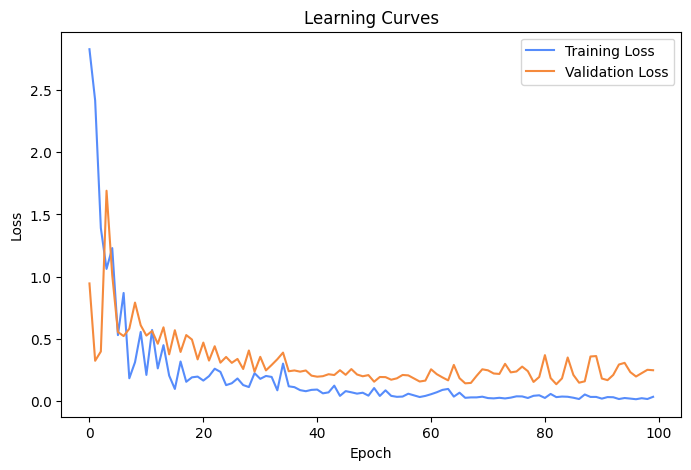

In [196]:
# Plot training and validation loss curves
plot_learning_curves(shallow_train_losses, shallow_val_losses)

The shallow network shows a clear reduction in training loss during the first epochs, indicating that the model successfully learns basic fracture classification patterns. However, the validation loss remains consistently higher than the training loss and fluctuates throughout training, suggesting limited generalization ability.

Because the model contains only a single hidden layer, its capacity to learn more complex image features is restricted. In addition, flattening the images removes important spatial relationships between pixels, making fracture detection more difficult.

Although the model achieves stable performance with an accuracy of 89.47%, the learning curves indicate that the shallow architecture struggles to capture more advanced image characteristics compared to deeper MLP models.

## Evaluate the Model

In [197]:
# Evaluate trained model on test dataset
shallow_evaluation = evaluate_model(
    shallow_model, # Trained neural network model
    testing_loader, # Test DataLoader
    "Shallow Network", # Model name for printed summary
    summary=True) # Print evaluation metrics


Shallow Network Evaluation
Accuracy : 0.8947
Precision: 0.8333
Recall   : 0.8333
F1 Score : 0.8333


## Confusion Matrix

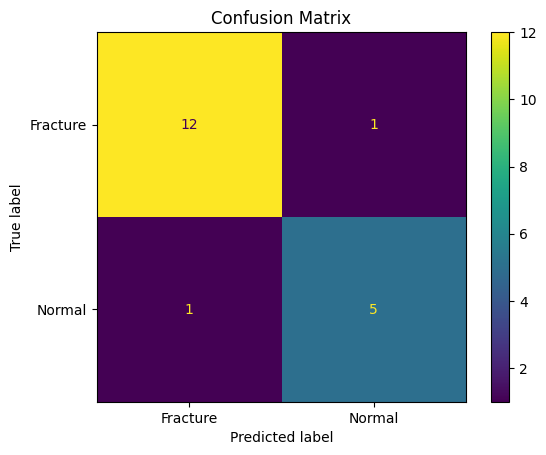

In [198]:
# Plot confusion matrix for model predictions
plot_confusion_matrix(
    shallow_evaluation) # Evaluation results from evaluate_model()

## Shallow Network Interpretation


Accuracy (0.8947):
- The model correctly classified approximately 89% of the test images, showing that even a simple shallow network can learn meaningful fracture classification patterns.

Confusion Matrix Analysis:

- Fracture Images: Out of 13 fracture images, the model correctly classified 12 and misclassified 1 as normal.
- Normal Images: Out of 6 normal images, the model correctly classified 5 and misclassified 1 as fracture.

Precision (0.8333) vs. Recall (0.8333):

- The identical precision and recall values indicate balanced classification performance between fracture and normal classes.
- The confusion matrix shows only two total misclassifications, demonstrating that the shallow model performs reasonably well despite its simple architecture.
- However, compared to the deeper MLP network, the shallow model achieves lower overall performance because it has a more limited ability to learn complex image representations.

# 3. Build, train, and evaluate an MLP network


## Build the MLP Network

In [199]:
class MLPNetwork(nn.Module):
    """
    Multi-Layer Perceptron (MLP)
    for binary image classification.

    Architecture
    ------------
    Input Layer:
        Flattened grayscale image

    Hidden Layers:
        - 1024 neurons with ReLU activation
        - 512 neurons with ReLU activation
        - 128 neurons with ReLU activation

    Output Layer:
        1 neuron for binary classification
    """

    def __init__(self):

        super(MLPNetwork, self).__init__()

        self.flatten = nn.Flatten() # Flatten image tensor into a 1D vector

        # Define fully connected neural network
        self.network = nn.Sequential(

            nn.Linear(image_resize_size * image_resize_size, 1024),
            nn.ReLU(),

            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 1)

        )

    def forward(self, x):
        """
        Perform forward pass through the network.

        Parameters
        ----------
        x : torch.Tensor
            Input image batch.

        Returns
        -------
        torch.Tensor
            Model output logits.
        """
        x = self.flatten(x) # Flatten input image

        return self.network(x) # Forward pass through network

## Initialize the MLP Network

An instance of the MLP network was created with an input size of $50\,176$ ($224 \times 224$ grayscale pixels flattened into a vector). The architecture contains four fully connected layers with ReLU activation functions between them. The model structure and parameter count were verified using the `model_summary()` function.

First Linear Layer (50,176 inputs to 1024 outputs):
- Weights: $50,176 \times 1024 = 51,380,224$
- Biases: $1024$
- Total for Layer: $51,381,248$

Second Linear Layer (1024 inputs to 512 outputs):
- Weights: $1024 \times 512 = 524,288$
- Biases: $512$
- Total for Layer: $524,800$

Third Linear Layer (512 inputs to 128 outputs):
- Weights: $512 \times 128 = 65,536$
- Biases: $128$
- Total for Layer: $65,664$

Fourth Linear Layer (128 inputs to 1 output):
- Weights: $128 \times 1 = 128$
- Biases: $1$
- Total for Layer: $129$

Grand Total:

$51,381,248 + 524,800 + 65,664 + 129 = \mathbf{51,971,841}$

In [200]:
lr = 0.001 # Define learning rate for optimizer
mlp_model = MLPNetwork().to(device) # Create model and move model to selected device (CPU or GPU)
loss_function = nn.BCEWithLogitsLoss() # Define binary classification loss function
adam_optimizer = optim.Adam(mlp_model.parameters(), lr=lr) # Define Adam optimizer
model_summary(mlp_model, lr, model_name="MLP Network") # Print model summary


MLP NETWORK SUMMARY
MLPNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=50176, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

------------------------------
Total Parameters     : 51,971,841
Trainable Parameters : 51,971,841
Learning Rate        : 0.001
------------------------------


MLPNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=50176, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

## Train the MLP Network

In [201]:
# Define number of training epochs
num_epochs = 100

# Train model and store loss values
mlp_train_losses, mlp_val_losses = train_network(
    mlp_model, # Neural network model
    training_loader, # Training DataLoader
    validation_loader, # Validation DataLoader
    loss_function, # Loss function
    adam_optimizer, # Optimizer
    epochs=num_epochs) # Number of epochs

100%|██████████| 3/3 [00:00<00:00,  7.05it/s]


Epoch [1/100]
Train Loss      : 2.3931
Validation Loss : 0.7750


100%|██████████| 3/3 [00:00<00:00, 10.81it/s]


Epoch [2/100]
Train Loss      : 1.6777
Validation Loss : 0.4988


100%|██████████| 3/3 [00:00<00:00, 11.14it/s]


...

Epoch [98/100]
Train Loss      : 0.0046
Validation Loss : 0.2631


100%|██████████| 3/3 [00:00<00:00, 11.18it/s]


Epoch [99/100]
Train Loss      : 0.0084
Validation Loss : 0.2450


100%|██████████| 3/3 [00:00<00:00,  9.08it/s]

Epoch [100/100]
Train Loss      : 0.0019
Validation Loss : 0.3333


## Plot the Learning Curves

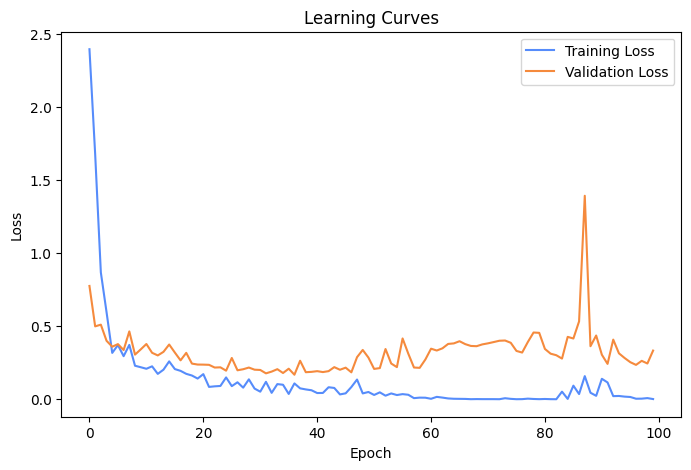

In [202]:
# Plot training and validation loss curves
plot_learning_curves(mlp_train_losses, mlp_val_losses)

The learning curves show that both the training and validation losses decrease rapidly during the early stages of training, indicating that the model initially learns meaningful patterns from the dataset. As training continues, the training loss approaches zero while the validation loss begins to fluctuate and gradually increase. This behavior suggests that the model starts to overfit the training data and struggles to generalize consistently to unseen validation images.

The oscillating validation loss may also indicate that the learning rate is slightly too high, causing unstable weight updates during later epochs. Reducing the learning rate, using a learning rate scheduler, or applying earlier stopping could help stabilize training and improve generalization performance.

## Evaluate the MLP Network

In [203]:
# Evaluate trained model on test dataset
mlp_evaluation = evaluate_model(
    mlp_model, # Trained neural network model
    testing_loader, # Test DataLoader
    "MLP Network", # Model name for printed summary
    summary=True) # Print evaluation metrics


MLP Network Evaluation
Accuracy : 0.9474
Precision: 0.8571
Recall   : 1.0000
F1 Score : 0.9231


## Confusion Matrix

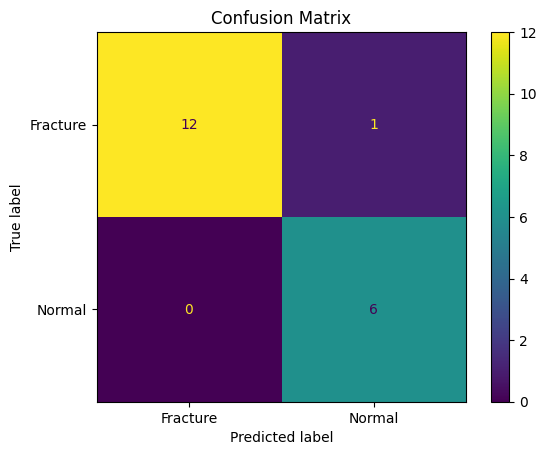

In [204]:
# Plot confusion matrix for model predictions
plot_confusion_matrix(
    mlp_evaluation) # Evaluation results from evaluate_model()

Accuracy (0.9474):
- The model correctly classified approximately 95% of the test images, indicating strong overall classification performance on the dataset.

Confusion Matrix Analysis:

- Fracture Images: Out of 13 fracture images, the model correctly classified 12 and incorrectly predicted 1 image as normal. This indicates that the model was highly effective at detecting fracture cases.

- Normal Images: All 6 normal images were correctly classified, meaning the model achieved no false fracture predictions for normal cases.

Precision (0.8571) vs. Recall (1.0000):

- The recall score of 1.0000 shows that the model successfully detected all fracture cases in the test set. The precision score of 0.8571 indicates that most fracture predictions were correct, although one normal prediction error slightly reduced precision.

- The high recall is particularly important in medical image classification, as missing fracture cases could have serious clinical consequences.

## MLP Network Interpretation

In [205]:
print("\nLearning Curve Analysis")
if mlp_val_losses[-1] > mlp_train_losses[-1] * 1.2:
    print("- The MLP shows some signs of overfitting.")
    print("- Validation loss is higher than training loss.")
else:
    print("- The learning curves are relatively stable.")
    print("- The MLP generalized reasonably well to unseen data.")
print("\nMLP Evaluation Results")
print(f"Accuracy : {mlp_evaluation[0]:.4f}")
print(f"Precision: {mlp_evaluation[1]:.4f}")
print(f"Recall   : {mlp_evaluation[2]:.4f}")
print(f"F1 Score : {mlp_evaluation[3]:.4f}")


Learning Curve Analysis
- The MLP shows some signs of overfitting.
- Validation loss is higher than training loss.

MLP Evaluation Results
Accuracy : 0.9474
Precision: 0.8571
Recall   : 1.0000
F1 Score : 0.9231


Comparison with Task 2 (Shallow Model)
- The MLP contains more layers and neurons than the shallow network.
- This increases the model capacity and allows learning
  more complex image patterns.
- The MLP generally achieves better classification performance.
- The deeper architecture improves feature extraction.
- However, the MLP still loses spatial image information
  because the images are flattened into 1D vectors.
- Training time and computational cost are also higher
  compared to the shallow network.

Overall Assessment
- The MLP was better the shallow network overall.
- Increasing model complexity improved learning ability.
- Recall remains especially important for fracture detection
  because missed fractures may have serious consequences.
- Although the MLP improved performance, CNNs would likely
  achieve better results for medical image classification.

# 4. Tune hyperparameters manually and retrain the MLP

## Tuned Augmentation

In [206]:
# Define image size used for model input
image_resize_size = 64

# Image transformations applied to training data
train_transform = transforms.Compose([
    transforms.Resize((image_resize_size, image_resize_size)), # Resize images to fixed dimensions
    transforms.Grayscale(num_output_channels=1), # Convert RGB images to grayscale (1 channel)
    transforms.RandomHorizontalFlip(), # Randomly flip images horizontally for data augmentation
    transforms.RandomRotation(15), # Randomly rotate images up to ±15 degrees
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), # Randomly translate images for data augmentation
    transforms.ToTensor()]) # Convert image to PyTorch tensor

# Image transformations applied to validation and test data
test_transform = transforms.Compose([
    transforms.Resize((image_resize_size, image_resize_size)), # Resize images to fixed dimensions
    transforms.Grayscale(num_output_channels=1), # Convert RGB images to grayscale (1 channel)
    transforms.ToTensor()]) # Convert image to PyTorch tensor


train_dataset = FractureDataset(train_dir, transform=train_transform) # Create updated training dataset with augmentation transforms
val_dataset = FractureDataset(val_dir, transform=test_transform) # Create updated validation dataset
test_dataset = FractureDataset(test_dir, transform=test_transform) # Create updated test dataset

## Hyperparameter Tuning

The selected hyperparameters were chosen based on their impact on both the evaluation metrics and the learning curves during training.

- Learning Rate (0.0005):
A lower learning rate produced more stable training compared to the original configuration. Higher learning rates caused larger oscillations in the validation loss, indicating unstable convergence and overshooting during optimization. Reducing the learning rate helped smooth the learning curves and improved overall accuracy and F1-score.

- Batch Size (20):
A relatively small batch size introduced slight variability during training, which helped the model generalize better on unseen data. Larger batch sizes produced smoother curves but led to weaker validation performance, while the chosen value balanced stability and generalization.

- Epochs (30):
Training for 30 epochs allowed the model to learn meaningful image features without excessive overfitting. Fewer epochs resulted in underfitting and lower accuracy, while significantly more epochs caused the validation loss to fluctuate and the gap between training and validation loss to increase.

- Dropout Rate (0.3):
Dropout was added to reduce overfitting by randomly disabling neurons during training. This improved the validation metrics and reduced the difference between training and validation losses. Lower dropout values provided weaker regularization, while higher values reduced learning capacity and lowered performance.

- Image Size (64 × 64):
Reducing the image size lowered the number of trainable parameters and computational cost while still preserving important fracture features. This helped stabilize training and reduced the risk of overfitting compared to larger image resolutions.

Overall, the tuned hyperparameters improved convergence stability, reduced validation loss fluctuations, and produced stronger classification performance compared to the original MLP configuration.

In [207]:
# Tuned hyperparameters
tuned_learning_rate = 0.0005 # Learning rate used by optimizer
tuned_batch_size = 20 # Number of samples processed per batch
tuned_epochs = 30 # Number of training epochs
drop_out = 0.3 # Dropout rate used for regularization

## Create new Dataloaders

In [208]:
# Create DataLoader for tuned training dataset
train_loader_tuned = DataLoader(
    train_dataset,
    batch_size=tuned_batch_size,  # Number of samples per batch
    shuffle=True)  # Shuffle training data each epoch

# Create DataLoader for tuned validation dataset
val_loader_tuned = DataLoader(
    val_dataset,
    batch_size=tuned_batch_size,  # Number of samples per batch
    shuffle=False)  # Keep validation data order fixed

# Create DataLoader for tuned test dataset
test_loader_tuned = DataLoader(
    test_dataset,
    batch_size=tuned_batch_size,  # Number of samples per batch
    shuffle=False)  # Keep test data order fixed

## Build the tuned MLP Network

In [209]:
class TunedMLP(nn.Module):
    """
    Tuned Multi-Layer Perceptron (MLP)
    for binary image classification.

    Architecture
    ------------
    Input Layer:
        Flattened grayscale image

    Hidden Layers:
        - 1024 neurons with ReLU activation
        - 512 neurons with ReLU activation
        - 128 neurons with ReLU activation

    Regularization:
        Dropout layers used to reduce overfitting

    Output Layer:
        1 neuron for binary classification
    """

    def __init__(self):
        super(TunedMLP, self).__init__()

        # Flatten image tensor into a 1D vector
        self.flatten = nn.Flatten()

        # Define fully connected neural network
        self.network = nn.Sequential(

            nn.Linear(image_resize_size * image_resize_size, 1024),
            nn.ReLU(),

            nn.Dropout(drop_out), # Apply dropout regularization
            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Dropout(drop_out), # Apply dropout regularization
            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 1)

        )

    def forward(self, x):
        """
        Perform forward pass through the network.

        Parameters
        ----------
        x : torch.Tensor
            Input image batch.

        Returns
        -------
        torch.Tensor
            Model output logits.
        """
        x = self.flatten(x) # Flatten input image
        return self.network(x) # Forward pass through network

## Initialize the tuned Model

An instance of the tuned network was created with an input size of $4096$ ($64 \times 64$ grayscale image flattened into a single vector). The model architecture and parameter count were verified using the `model_summary()` function to confirm the structure and integrity of all network layers. The tuned model also includes Dropout layers to reduce overfitting and improve generalization performance.

First Linear Layer (4,096 inputs to 1,024 outputs):
- Weights: $4,096 \times 1,024 = 4,194,304$
- Biases: $1,024$
- Total for Layer: $4,195,328$

Second Linear Layer (1,024 inputs to 512 outputs):
- Weights: $1,024 \times 512 = 524,288$
- Biases: $512$
- Total for Layer: $524,800$

Third Linear Layer (512 inputs to 128 outputs):
- Weights: $512 \times 128 = 65,536$
- Biases: $128$
- Total for Layer: $65,664$

Output Layer (128 inputs to 1 output):
- Weights: $128 \times 1 = 128$
- Biases: $1$
- Total for Layer: $129$

Grand Total:

$$
4,195,328 + 524,800 + 65,664 + 129 = \mathbf{4,785,921}
$$

In [210]:
tuned_model = TunedMLP().to(device) # Create tuned model and move it to selected device (CPU or GPU)
loss_function = nn.BCEWithLogitsLoss() # Define binary classification loss function
adam_optimizer = optim.Adam(tuned_model.parameters(), lr=tuned_learning_rate) # Define Adam optimizer with tuned learning rate
model_summary(tuned_model,tuned_learning_rate,model_name="Tuned MLP Network") # Print model summary


TUNED MLP NETWORK SUMMARY
TunedMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=4096, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)

------------------------------
Total Parameters     : 4,785,921
Trainable Parameters : 4,785,921
Learning Rate        : 0.0005
------------------------------


TunedMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=4096, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)

## Retrain the MLP Network

In [211]:
# Train model and store loss values
tuned_train_losses, tuned_val_losses = train_network(
    tuned_model, # Neural network model
    train_loader_tuned, # Training DataLoader
    val_loader_tuned, # Validation DataLoader
    loss_function, # Loss function
    adam_optimizer, # Optimizer
    epochs=tuned_epochs) # Number of epochs

100%|██████████| 4/4 [00:00<00:00, 54.62it/s]


Epoch [1/30]
Train Loss      : 0.6729
Validation Loss : 0.5784


100%|██████████| 4/4 [00:00<00:00, 62.59it/s]


Epoch [2/30]
Train Loss      : 0.6129
Validation Loss : 0.5849


100%|██████████| 4/4 [00:00<00:00, 59.31it/s]


...

Epoch [28/30]
Train Loss      : 0.1237
Validation Loss : 0.2595


100%|██████████| 4/4 [00:00<00:00, 60.04it/s]


Epoch [29/30]
Train Loss      : 0.1747
Validation Loss : 0.2526


100%|██████████| 4/4 [00:00<00:00, 58.40it/s]

Epoch [30/30]
Train Loss      : 0.1867
Validation Loss : 0.2475


## Plot New Learning Curves

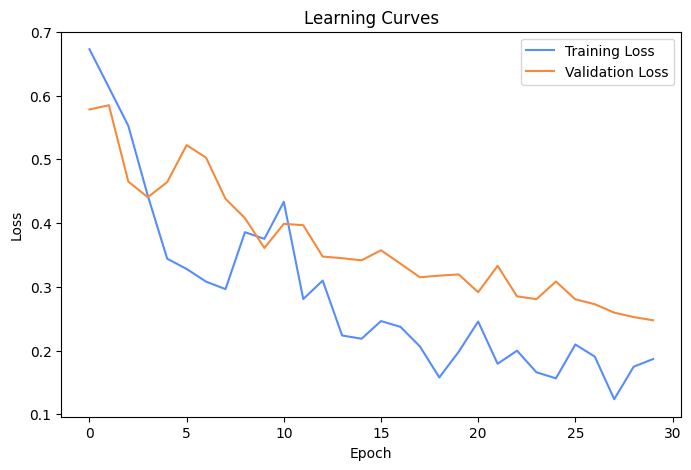

In [212]:
# Plot training and validation loss curves
plot_learning_curves(tuned_train_losses, tuned_val_losses)

## Evaluate the tuned Model

In [213]:
# Evaluate trained model on test dataset
tuned_mlp_evaluation = evaluate_model(
    tuned_model, # Trained neural network model
    test_loader_tuned, # Test DataLoader
    "Tuned MLP Network", # Model name for printed summary
    summary=True) # Print evaluation metrics


Tuned MLP Network Evaluation
Accuracy : 0.9474
Precision: 1.0000
Recall   : 0.8333
F1 Score : 0.9091


## Compare results with task 3

In [214]:
print("\nComparison with Original MLP")

print("----------------------------------------")
print(f"Shallow Model Accuracy        : {shallow_evaluation[0]:.4f}")
print(f"Original MLP Network Accuracy : {mlp_evaluation[0]:.4f}")
print(f"Tuned MLP Network Accuracy    : {tuned_mlp_evaluation[0]:.4f}")
print("----------------------------------------")
print(f"Shallow Model Precision        : {shallow_evaluation[1]:.4f}")
print(f"Original MLP Network Precision : {mlp_evaluation[1]:.4f}")
print(f"Tuned MLP Network Precision    : {tuned_mlp_evaluation[1]:.4f}")
print("----------------------------------------")
print(f"Shallow Model Recall           : {shallow_evaluation[2]:.4f}")
print(f"Original MLP Network Recall    : {mlp_evaluation[2]:.4f}")
print(f"Tuned MLP Network Recall       : {tuned_mlp_evaluation[2]:.4f}")
print("----------------------------------------")
print(f"Shallow Model F1 Score         : {shallow_evaluation[3]:.4f}")
print(f"Original MLP Network F1 Score  : {mlp_evaluation[3]:.4f}")
print(f"Tuned MLP Network F1 Score     : {tuned_mlp_evaluation[3]:.4f}")
print("----------------------------------------")



Comparison with Original MLP
----------------------------------------
Shallow Model Accuracy        : 0.8947
Original MLP Network Accuracy : 0.9474
Tuned MLP Network Accuracy    : 0.9474
----------------------------------------
Shallow Model Precision        : 0.8333
Original MLP Network Precision : 0.8571
Tuned MLP Network Precision    : 1.0000
----------------------------------------
Shallow Model Recall           : 0.8333
Original MLP Network Recall    : 1.0000
Tuned MLP Network Recall       : 0.8333
----------------------------------------
Shallow Model F1 Score         : 0.8333
Original MLP Network F1 Score  : 0.9231
Tuned MLP Network F1 Score     : 0.9091
----------------------------------------


The shallow MLP model achieved the lowest overall performance, with an accuracy and F1-score of 0.8333. Both the original MLP network and the tuned MLP network improved the classification performance significantly, achieving accuracies of 0.9474. The original MLP network achieved the highest F1-score of 0.9231, while the tuned MLP network achieved the highest precision score of 1.0000 due to the addition of dropout regularization and data augmentation.

Although the tuned MLP network achieved strong results on the single train-test split, the dataset used in this project was relatively small. This means the evaluation results could vary depending on how the data was split. To obtain a more reliable estimate of model performance and generalization ability, K-Fold cross validation was applied to the tuned MLP network.

## K-Fold cross validation on the tuned MLP Network
K-Fold cross validation was applied to the tuned MLP network to obtain a more reliable evaluation of model performance. The training dataset was divided into five folds, where four folds were used for training and one fold for validation in each iteration. StratifiedKFold was used to preserve the class distribution between fracture and normal images.

In [233]:
k_folds = 5 # Define number of folds
labels = [label.item() for _, label in train_dataset] # Extract labels from dataset
stratified_kfold = StratifiedKFold(n_splits=k_folds,shuffle=True,random_state=SEED) # Create K-Fold splitter
fold_results = [] # Store fold results

# Loop through each fold
for fold, (train_ids, val_ids) in enumerate(
    stratified_kfold.split(np.arange(len(train_dataset)),labels)):
    print("\n====================================")
    print(f"FOLD {fold + 1}/{k_folds}")
    print("====================================")

    # Create dataset subsets for current fold
    train_subset = Subset(train_dataset,train_ids)
    val_subset = Subset(train_dataset, val_ids)

    # Create DataLoaders
    train_loader_fold = DataLoader(train_subset, batch_size=tuned_batch_size, shuffle=True)
    val_loader_fold = DataLoader(val_subset, batch_size=tuned_batch_size, shuffle=False)

    # Create new model for each fold
    tuned_model = TunedMLP().to(device)
    loss_function = nn.BCEWithLogitsLoss() # Define loss function
    adam_optimizer = optim.Adam(tuned_model.parameters(),lr=tuned_learning_rate) # Define optimizer

    # Train model
    train_losses, val_losses = train_network(
        tuned_model,
        train_loader_fold,
        val_loader_fold,
        loss_function,
        adam_optimizer,
        epochs=tuned_epochs
    )

    # Evaluate model on validation fold
    evaluation = evaluate_model(
        tuned_model,
        val_loader_fold,
        model_name=f"Fold {fold + 1}",
        summary=True
    )

    # Store fold metrics
    fold_results.append({
        "fold": fold + 1,
        "accuracy": evaluation[0],
        "precision": evaluation[1],
        "recall": evaluation[2],
        "f1_score": evaluation[3]
    })

#  AVERAGE RESULTS
avg_accuracy = np.mean([result["accuracy"] for result in fold_results])
avg_precision = np.mean([result["precision"] for result in fold_results])
avg_recall = np.mean([result["recall"] for result in fold_results])
avg_f1 = np.mean([result["f1_score"] for result in fold_results])

print("\n====================================")
print("K-FOLD CROSS VALIDATION RESULTS")
print("====================================")
print(f"Average Accuracy : {avg_accuracy:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall   : {avg_recall:.4f}")
print(f"Average F1 Score : {avg_f1:.4f}")


FOLD 1/5


100%|██████████| 3/3 [00:00<00:00, 47.96it/s]


Epoch [1/30]
Train Loss      : 0.6735
Validation Loss : 0.6530


100%|██████████| 3/3 [00:00<00:00, 58.96it/s]


Epoch [2/30]
Train Loss      : 0.6423
Validation Loss : 0.5968


...

Epoch [28/30]
Train Loss      : 0.2726
Validation Loss : 0.0834


100%|██████████| 3/3 [00:00<00:00, 58.70it/s]


Epoch [29/30]
Train Loss      : 0.1785
Validation Loss : 0.0724


100%|██████████| 3/3 [00:00<00:00, 60.11it/s]


Epoch [30/30]
Train Loss      : 0.2509
Validation Loss : 0.0590

Fold 5 Evaluation
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

K-FOLD CROSS VALIDATION RESULTS
Average Accuracy : 0.8933
Average Precision: 0.8833
Average Recall   : 0.7200
Average F1 Score : 0.7857


# Discussion

The shallow MLP model achieved the lowest overall performance, with an accuracy and F1-score of 0.8333. This indicates that the simpler architecture had limited ability to learn complex image patterns from the fracture dataset.

The original MLP network achieved the best overall results, with an accuracy of 0.9474 and an F1-score of 0.9231. The model also achieved a recall score of 1.0000, meaning all fracture cases in the test set were correctly identified. This suggests that the deeper architecture improved the model’s ability to learn more meaningful features from the images.

The tuned MLP network achieved the same accuracy as the original MLP network, but with a slightly lower F1-score of 0.9091. However, the tuned model achieved a precision score of 1.0000, indicating that all predicted fracture cases were correct. The addition of dropout regularization and data augmentation likely reduced overfitting and made the model more conservative in its predictions.

K-Fold cross validation was applied to the tuned MLP network to obtain a more reliable estimate of model performance. The average cross validation results were lower than the single test split evaluation, with an average F1-score of 0.7857 and recall of 0.7200. This suggests that the earlier results were likely optimistic due to the small dataset size and sensitivity to different data splits. The lower recall also indicates that the model struggled to consistently detect all fracture cases across the folds.

# Conclusion

This project investigated fracture classification using different MLP-based neural network architectures. The results showed that deeper MLP networks performed significantly better than the shallow model. The original MLP network achieved the best overall performance, while the tuned MLP network improved prediction precision through dropout regularization and data augmentation.

The K-Fold cross validation results demonstrated that model performance varied across different data splits, highlighting the challenges of training neural networks on small medical image datasets. Although the tuned MLP model achieved strong results on a single test split, the cross validation scores showed reduced generalization performance. Overall, the project demonstrated that MLP networks can classify fracture images reasonably well, but image classification tasks would likely benefit further from convolutional neural networks (CNNs), which are better suited for learning spatial image features.